# SBV2 06 - Schema Normalisation

This notebook promotes Notebook 04 PaddleOCR output to the primary extraction source, normalises OCR regions into the menu-generation schema, and keeps Notebook 05 PaddleOCR-VL as diagnostic context only.

Qwen2.5-VL is prepared here as an optional local critic. It reviews OCR-derived schema rows after deterministic normalisation; it is not required to create the schema.

## Contract

Inputs:

- `data/interim/sandbox_v2/manifests/sbv2_03_document_manifest.csv`
- `data/interim/sandbox_v2/manifests/sbv2_04_ocr_sample_manifest.csv`
- `data/interim/sandbox_v2/ocr_outputs/sbv2_04_ocr_text_regions.csv`
- `outputs/sandbox_v2/audit_tables/sbv2_04_ocr_document_summary.csv`
- optional diagnostic context from `outputs/sandbox_v2/audit_tables/sbv2_05_vl_document_summary.csv`
- optional Qwen critic files: `models/Qwen_Qwen2.5-VL-7B-Instruct-Q4_K_M.gguf` and `models/mmproj-Qwen_Qwen2.5-VL-7B-Instruct-f16.gguf`

Outputs:

- `data/processed/sandbox_v2/menu_generation_schema.csv`
- `data/processed/sandbox_v2/menu_generation_schema.parquet`
- `data/interim/sandbox_v2/schema_outputs/sbv2_06_menu_generation_schema.csv`
- `data/interim/sandbox_v2/schema_outputs/sbv2_06_qwen_critic_prompts.jsonl`
- schema audit tables and Qwen runtime plan under `outputs/sandbox_v2/audit_tables/`
- schema row chart under `outputs/figures/sandbox_v2/`

In [2]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "sandbox_v2").exists():
    candidates = [parent for parent in ROOT.parents if (parent / "sandbox_v2").exists()]
    if candidates:
        ROOT = candidates[0]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

CACHE_DIR = Path(os.environ.get("MENUFORGE_CACHE_HOME", ROOT / ".cache")).resolve()
for env_name, relative_path in {
    "XDG_CACHE_HOME": "",
    "PADDLE_PDX_CACHE_HOME": "paddlex",
    "MPLCONFIGDIR": "matplotlib",
    "JUPYTER_CONFIG_DIR": "jupyter_config",
    "JUPYTER_DATA_DIR": "jupyter_data",
    "JUPYTER_RUNTIME_DIR": "jupyter_runtime",
    "IPYTHONDIR": "ipython",
    "HF_HOME": "huggingface",
    "TORCH_HOME": "torch",
}.items():
    target = (CACHE_DIR / relative_path) if relative_path else CACHE_DIR
    target.mkdir(parents=True, exist_ok=True)
    os.environ.setdefault(env_name, str(target))

print({"ROOT": str(ROOT), "CACHE_DIR": str(CACHE_DIR)})

{'ROOT': '/home/endy/menuforge', 'CACHE_DIR': '/home/endy/menuforge/.cache'}


In [3]:
# Deterministic OCR-to-schema run. This is the main Notebook 06 deliverable.
RUN_SCHEMA = True

# Qwen is prepared as a local critic. Turn this on only after the schema preview looks sane.
RUN_QWEN_CRITIC = False
QWEN_MAX_DOCS = 1
QWEN_MAX_SCHEMA_ROWS = 25

# Usually False. If a menu document produces no item rows, this can preserve OCR lines as fallback rows.
INCLUDE_TEXT_LINE_FALLBACK = False

print({
    "RUN_SCHEMA": RUN_SCHEMA,
    "RUN_QWEN_CRITIC": RUN_QWEN_CRITIC,
    "QWEN_MAX_DOCS": QWEN_MAX_DOCS,
    "QWEN_MAX_SCHEMA_ROWS": QWEN_MAX_SCHEMA_ROWS,
    "INCLUDE_TEXT_LINE_FALLBACK": INCLUDE_TEXT_LINE_FALLBACK,
})

{'RUN_SCHEMA': True, 'RUN_QWEN_CRITIC': False, 'QWEN_MAX_DOCS': 1, 'QWEN_MAX_SCHEMA_ROWS': 25, 'INCLUDE_TEXT_LINE_FALLBACK': False}


### Preflight

Notebook 06 should run from OCR outputs even if Qwen critic is disabled. Qwen files are checked so you know whether the optional critic path is ready.

In [4]:
preflight = {
    "sbv2_03_manifest": (ROOT / "data/interim/sandbox_v2/manifests/sbv2_03_document_manifest.csv").exists(),
    "sbv2_04_ocr_sample": (ROOT / "data/interim/sandbox_v2/manifests/sbv2_04_ocr_sample_manifest.csv").exists(),
    "sbv2_04_ocr_regions": (ROOT / "data/interim/sandbox_v2/ocr_outputs/sbv2_04_ocr_text_regions.csv").exists(),
    "sbv2_04_ocr_doc_summary": (ROOT / "outputs/sandbox_v2/audit_tables/sbv2_04_ocr_document_summary.csv").exists(),
    "sbv2_05_vl_doc_summary_optional": (ROOT / "outputs/sandbox_v2/audit_tables/sbv2_05_vl_document_summary.csv").exists(),
    "qwen_gguf_optional": (ROOT / "models/Qwen_Qwen2.5-VL-7B-Instruct-Q4_K_M.gguf").exists(),
    "qwen_mmproj_optional": (ROOT / "models/mmproj-Qwen_Qwen2.5-VL-7B-Instruct-f16.gguf").exists(),
}
for name, ok in preflight.items():
    print(f"  {'OK ' if ok else 'MISS'}  {name}")
required = ["sbv2_03_manifest", "sbv2_04_ocr_sample", "sbv2_04_ocr_regions", "sbv2_04_ocr_doc_summary"]
missing_required = [name for name in required if not preflight[name]]
if missing_required:
    raise FileNotFoundError(f"Preflight failed; missing required inputs: {missing_required}")

  OK   sbv2_03_manifest
  OK   sbv2_04_ocr_sample
  OK   sbv2_04_ocr_regions
  OK   sbv2_04_ocr_doc_summary
  OK   sbv2_05_vl_doc_summary_optional
  OK   qwen_gguf_optional
  OK   qwen_mmproj_optional


In [5]:
from sandbox_v2.schema_normalisation import write_outputs

summary_path = ROOT / "outputs" / "sandbox_v2" / "audit_tables" / "sbv2_06_schema_summary.json"
if RUN_SCHEMA:
    summary = write_outputs(
        run_qwen_critic_flag=RUN_QWEN_CRITIC,
        qwen_max_docs=QWEN_MAX_DOCS,
        qwen_max_schema_rows=QWEN_MAX_SCHEMA_ROWS,
        include_text_line_fallback=INCLUDE_TEXT_LINE_FALLBACK,
    )
elif summary_path.exists():
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
else:
    raise FileNotFoundError("RUN_SCHEMA is false and no previous SBV2 06 summary exists.")

print(json.dumps({
    "primary_engine": summary.get("primary_engine"),
    "sample_rows": summary.get("sample_rows"),
    "ocr_region_rows": summary.get("ocr_region_rows"),
    "schema_rows": summary.get("schema_rows"),
    "item_rows": summary.get("item_rows"),
    "priced_rows": summary.get("priced_rows"),
    "review_rows": summary.get("review_rows"),
    "qwen_critic_available": summary.get("qwen_critic_available"),
    "qwen_prompt_count": summary.get("qwen_prompt_count"),
    "qwen_run_status": summary.get("qwen_run_status"),
    "schema_figure": summary.get("schema_figure"),
}, indent=2))

{
  "primary_engine": "paddleocr_ppocrv5_en_cpu",
  "sample_rows": 8,
  "ocr_region_rows": 1485,
  "schema_rows": 277,
  "item_rows": 277,
  "priced_rows": 277,
  "review_rows": 20,
  "qwen_critic_available": true,
  "qwen_prompt_count": 1,
  "qwen_run_status": "not_run",
  "schema_figure": "outputs/figures/sandbox_v2/sbv2_06_schema_rows_by_source.png"
}


In [6]:
def _safe_read_csv(path, **kw):
    try:
        return pd.read_csv(path, **kw)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()

schema = _safe_read_csv(ROOT / summary["menu_generation_schema_csv"], low_memory=False)
doc_summary = _safe_read_csv(ROOT / summary["document_summary_csv"], low_memory=False)
source_summary = _safe_read_csv(ROOT / summary["source_summary_csv"], low_memory=False)
validation = _safe_read_csv(ROOT / summary["validation_issues_csv"], low_memory=False)
decision = _safe_read_csv(ROOT / summary["extraction_source_decision_csv"], low_memory=False)

display(Markdown("### Extraction Source Decision"))
display(decision)

display(Markdown("### Schema Source Summary"))
display(source_summary)

display(Markdown("### Schema Document Summary"))
display(doc_summary)

preview_cols = [
    "unified_document_id", "section_name", "item_name", "item_description", "price",
    "confidence", "needs_review", "review_reason", "normalisation_method",
]
display(Markdown("### Menu Schema Preview"))
display(schema[[col for col in preview_cols if col in schema.columns]].head(40))

display(Markdown("### Validation Issues"))
display(validation.head(40))

### Extraction Source Decision

,source_engine,decision,reason
0,paddleocr_ppocrv5_en_cpu,primary,NB04 OCR produced line-level boxes/text; NB05 ...
1,paddleocr_vl_0.9b_native_cpu,diagnostic_only,Observed outputs were coarse one-region docume...
2,qwen2.5_vl_7b_gguf_optional,optional_critic,Use local Qwen2.5-VL GGUF to review OCR-derive...


### Schema Source Summary

,source_id,documents,menu_candidate_docs,total_schema_rows,total_item_rows,total_priced_rows,total_review_rows,mean_confidence
0,cord,1,0,0,0,0,0,NaN
1,funsd,1,0,0,0,0,0,NaN
2,nypl,1,1,33,33,33,12,0.8231
3,nypl_expanded,1,1,123,123,123,4,0.9600
4,sroie,1,0,0,0,0,0,NaN
5,synthetic_menu_concepts,1,1,10,10,10,0,0.9965
6,wikimedia_commons_english_menus,1,1,37,37,37,1,0.9487
7,wikimedia_english_menus,1,1,74,74,74,3,0.9415


### Schema Document Summary

,unified_document_id,source_id,document_id,dataset_family,task_family,evaluation_scope,schema_status,primary_source,ocr_region_count,schema_rows,...,ground_truth_item_count,schema_item_name_hits,schema_price_hits,schema_item_name_coverage,schema_price_coverage,skip_reason,vl_status,vl_region_count,vl_text_char_count,vl_runtime_seconds
0,sroie__sroie_00000,sroie,sroie_00000,receipt,receipt_kv_ocr,receipt_kv_ground_truth,skipped_non_menu,NaN,45,0,...,NaN,NaN,NaN,NaN,NaN,document is not marked for menu extraction,ok,1,1,53.898
1,funsd__funsd_0,funsd,funsd_0,form,form_kv_ocr,form_kv_ground_truth,skipped_non_menu,NaN,27,0,...,NaN,NaN,NaN,NaN,NaN,document is not marked for menu extraction,ok,1,839,50.101
2,nypl__nypl_page_45078,nypl,nypl_page_45078,menu,menu_ocr_extraction,menu_extraction_candidate,candidate,paddleocr_ppocrv5_en_cpu,56,33,...,NaN,NaN,NaN,NaN,NaN,NaN,ok,1,20,54.404
3,nypl_expanded__nypl_expanded_144,nypl_expanded,nypl_expanded_144,menu,menu_ocr_extraction,menu_extraction_candidate,candidate,paddleocr_ppocrv5_en_cpu,138,123,...,NaN,NaN,NaN,NaN,NaN,NaN,ok,1,20,54.452
4,synthetic_menu_concepts__synthetic_menu_concep...,synthetic_menu_concepts,synthetic_menu_concept_0000,menu,menu_ocr_extraction,menu_extraction_candidate,candidate,paddleocr_ppocrv5_en_cpu,38,10,...,10.0,10.0,10.0,1.0,1.0,NaN,ok,1,555,45.459
5,wikimedia_commons_english_menus__wikimedia_com...,wikimedia_commons_english_menus,wikimedia_commons_0000,menu,menu_ocr_extraction,ocr_layout_sidecar,candidate,paddleocr_ppocrv5_en_cpu,247,37,...,NaN,NaN,NaN,NaN,NaN,NaN,ok,1,38,52.965
6,wikimedia_english_menus__wikimedia_menu_000,wikimedia_english_menus,wikimedia_menu_000,menu,menu_ocr_extraction,ocr_layout_sidecar,candidate,paddleocr_ppocrv5_en_cpu,845,74,...,NaN,NaN,NaN,NaN,NaN,NaN,ok,1,44,53.118
7,cord__cord_smoke_0000,cord,cord_smoke_0000,receipt,receipt_line_item_smoke,ocr_layout_sidecar,skipped_non_menu,NaN,89,0,...,NaN,NaN,NaN,NaN,NaN,document is not marked for menu extraction,ok,1,440,54.313


### Menu Schema Preview

,unified_document_id,section_name,item_name,item_description,price,confidence,needs_review,review_reason,normalisation_method
0,nypl__nypl_page_45078,ANTIPASTI- HORS D'OEUVRES,a.9-Tonno efagio alo,Insalata di polin. 65,l 0,0.6432,True,low_ocr_confidence,ocr_trailing_price_line
1,nypl__nypl_page_45078,MINESTRE- SOUPS,Brode Gelée madrilena ealdo,NaN,300,0.8299,False,NaN,ocr_trailing_price_line
2,nypl__nypl_page_45078,MINESTRE- SOUPS,Niso e rmechine in broda,NaN,300,0.8299,False,NaN,ocr_trailing_price_line
3,nypl__nypl_page_45078,MINESTRE- SOUPS,Capellind n fegatini in hrodo,NaN,200,0.8299,False,NaN,ocr_trailing_price_line
4,nypl__nypl_page_45078,MINESTRE- SOUPS,"ve (I wova, 25- Quadrucd e pisel in brodo",NaN,10,0.7182,True,low_ocr_confidence,ocr_trailing_price_line
5,nypl__nypl_page_45078,MINESTRE- SOUPS,"nara, 450 Feltuccine alha laelale",NaN,650,0.8165,True,low_ocr_confidence,ocr_trailing_price_line
6,nypl__nypl_page_45078,MINESTRE- SOUPS,Spaghetl alla amatriciana,NaN,450,0.8165,True,low_ocr_confidence,ocr_trailing_price_line
7,nypl__nypl_page_45078,MINESTRE- SOUPS,Crema d asparugh,NaN,250,0.8165,True,low_ocr_confidence,ocr_trailing_price_line
8,nypl__nypl_page_45078,MINESTRE- SOUPS,Rise alla greca S. Caha,NaN,l. 450,0.8515,False,NaN,ocr_trailing_price_line
9,nypl__nypl_page_45078,UOVA - EGGS,Omeletta con funghi,NaN,450,0.8583,False,NaN,ocr_trailing_price_line


### Validation Issues

,unified_document_id,schema_row_id,issue_type,severity,message
0,nypl__nypl_page_45078,nypl__nypl_page_45078__schema_0001,needs_review,warning,low_ocr_confidence
1,nypl__nypl_page_45078,nypl__nypl_page_45078__schema_0005,needs_review,warning,low_ocr_confidence
2,nypl__nypl_page_45078,nypl__nypl_page_45078__schema_0006,needs_review,warning,low_ocr_confidence
3,nypl__nypl_page_45078,nypl__nypl_page_45078__schema_0007,needs_review,warning,low_ocr_confidence
4,nypl__nypl_page_45078,nypl__nypl_page_45078__schema_0008,needs_review,warning,low_ocr_confidence
5,nypl__nypl_page_45078,nypl__nypl_page_45078__schema_0012,needs_review,warning,low_ocr_confidence
6,nypl__nypl_page_45078,nypl__nypl_page_45078__schema_0013,needs_review,warning,low_ocr_confidence
7,nypl__nypl_page_45078,nypl__nypl_page_45078__schema_0014,needs_review,warning,low_ocr_confidence
8,nypl__nypl_page_45078,nypl__nypl_page_45078__schema_0015,needs_review,warning,low_ocr_confidence
9,nypl__nypl_page_45078,nypl__nypl_page_45078__schema_0018,needs_review,warning,low_ocr_confidence


### OCR-Derived Schema Rows

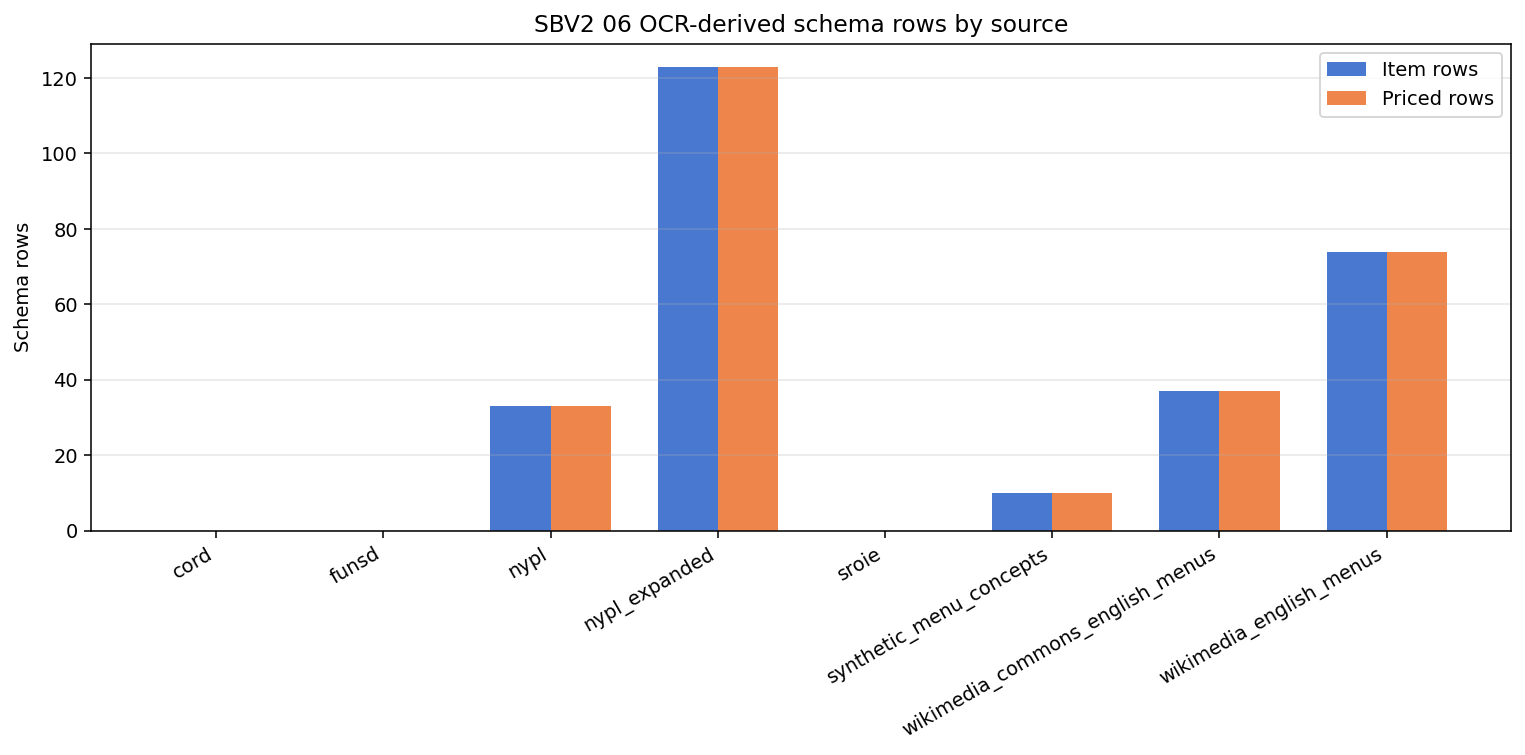

In [7]:
schema_figure = summary.get("schema_figure")
if schema_figure and (ROOT / schema_figure).exists():
    display(Markdown("### OCR-Derived Schema Rows"))
    display(Image(filename=str(ROOT / schema_figure)))
else:
    display(Markdown("_Schema figure was not produced._"))

In [8]:
qwen_plan_path = ROOT / summary["qwen_critic_plan_json"]
qwen_plan = json.loads(qwen_plan_path.read_text(encoding="utf-8"))
display(Markdown("### Optional Qwen Critic Runtime Plan"))
print(json.dumps({
    "available": qwen_plan.get("available"),
    "model_exists": qwen_plan.get("model_exists"),
    "mmproj_exists": qwen_plan.get("mmproj_exists"),
    "llama_cpp_available": qwen_plan.get("llama_cpp_available"),
    "llama_gpu_offload_available": qwen_plan.get("llama_gpu_offload_available"),
    "llama_gpu_offload_message": qwen_plan.get("llama_gpu_offload_message"),
    "qwen25vl_handler_available": qwen_plan.get("qwen25vl_handler_available"),
    "cuda_available": qwen_plan.get("cuda_available"),
    "cuda_device": qwen_plan.get("cuda_device"),
    "recommended_mode": qwen_plan.get("recommended_mode"),
    "runtime_settings": qwen_plan.get("runtime_settings"),
    "prompt_count": qwen_plan.get("prompt_count"),
    "run_summary": qwen_plan.get("run_summary"),
}, indent=2))

prompt_path = ROOT / qwen_plan["prompts_jsonl"]
if prompt_path.exists() and prompt_path.stat().st_size:
    first_prompt = json.loads(prompt_path.read_text(encoding="utf-8").splitlines()[0])
    display(Markdown("### First Qwen Critic Prompt Preview"))
    print(json.dumps({
        "unified_document_id": first_prompt.get("unified_document_id"),
        "image_path": first_prompt.get("image_path"),
        "schema_row_count": first_prompt.get("schema_row_count"),
        "prompt_preview": first_prompt.get("prompt", "")[:1800],
    }, indent=2))
else:
    display(Markdown("_No Qwen critic prompts were produced._"))

### Optional Qwen Critic Runtime Plan

{
  "available": true,
  "model_exists": true,
  "mmproj_exists": true,
  "llama_cpp_available": true,
  "llama_gpu_offload_available": true,
  "llama_gpu_offload_message": "ggml_cuda_init: found 1 CUDA devices (Total VRAM: 8187 MiB):\n  Device 0: NVIDIA GeForce RTX 4060 Laptop GPU, compute capability 8.9, VMM: yes, VRAM: 8187 MiB",
  "qwen25vl_handler_available": true,
  "cuda_available": true,
  "cuda_device": "NVIDIA GeForce RTX 4060 Laptop GPU",
  "recommended_mode": "gpu_cpu_offload",
  "runtime_settings": {
    "n_gpu_layers": -1,
    "n_ctx": 4096,
    "n_threads": 8,
    "n_batch": 512,
    "main_gpu": 0,
    "max_docs": 1,
    "temperature": 0.1,
    "max_tokens": 512,
    "workload_note": "llama.cpp GGUF path: offload model layers to the RTX 4060 when possible, keep CPU threads active for remaining ops and sampling; do not load PaddleOCR-VL at the same time."
  },
  "prompt_count": 1,
  "run_summary": {
    "status": "not_run",
    "processed": 0,
    "message": "RUN_QWEN_CRI

### First Qwen Critic Prompt Preview

{
  "unified_document_id": "synthetic_menu_concepts__synthetic_menu_concept_0000",
  "image_path": "data/raw/sandbox_v2/synthetic_menu_concepts/images/synthetic_menu_concept_0000.jpg",
  "schema_row_count": 10,
  "prompt_preview": "You are a strict menu extraction critic. Review the OCR-derived schema rows against the menu image. Do not invent menu items. Return compact JSON only with keys: score_0_1, accept_rows, reject_rows, missing_items, price_corrections, notes. Prefer preserving OCR evidence when uncertain.\n\nDocument: synthetic_menu_concepts__synthetic_menu_concept_0000\nSource: synthetic_menu_concepts\nOCR schema rows:\n[\n  {\n    \"row_id\": \"synthetic_menu_concepts__synthetic_menu_concept_0000__schema_0001\",\n    \"section\": \"SMALL PLATES\",\n    \"item\": \"Oyster Mushroom Tart\",\n    \"description\": \"berved with house pickles\",\n    \"price\": \"$ 15.00\",\n    \"bbox\": \"[68.0, 323.0, 494.0, 347.0]\",\n    \"review_reason\": \"\"\n  },\n  {\n    \"row_id\": \"sy

## Handoff to Notebook 07

Notebook 07 should evaluate `data/processed/sandbox_v2/menu_generation_schema.csv` against available ground truth.

Key interpretation for the pipeline:

- PaddleOCR is now the primary extraction source.
- PaddleOCR-VL remains diagnostic evidence, not the source of schema rows.
- Qwen2.5-VL can be used as an optional critic over schema candidates, starting with `QWEN_MAX_DOCS = 1`.
- Exact menu rendering or generation should consume the schema only after Notebook 07/08 marks rows or documents as ready.